### Time Series Analysis of Wikipedia Page Views (part 3) - Prediction with Neural Networks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential

In [76]:
from tensorflow.keras.layers import SimpleRNN, Dense, LSTM
from tensorflow.keras import Input
from tensorflow.keras.losses import Huber

Additional functions:

In [3]:
def custom_grid(plt):
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.grid(True, linestyle='--', alpha=0.6)

#### Time series

In [100]:
df = pd.read_csv("movie-pageviews.csv")

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.rename(columns={'Eyes Wide Shut': 'Views'}, inplace=True)

print(df.shape)
df.head(3)

(123, 1)


,Views
Date,
2015-07-01,133772
2015-08-01,121582
2015-09-01,93157


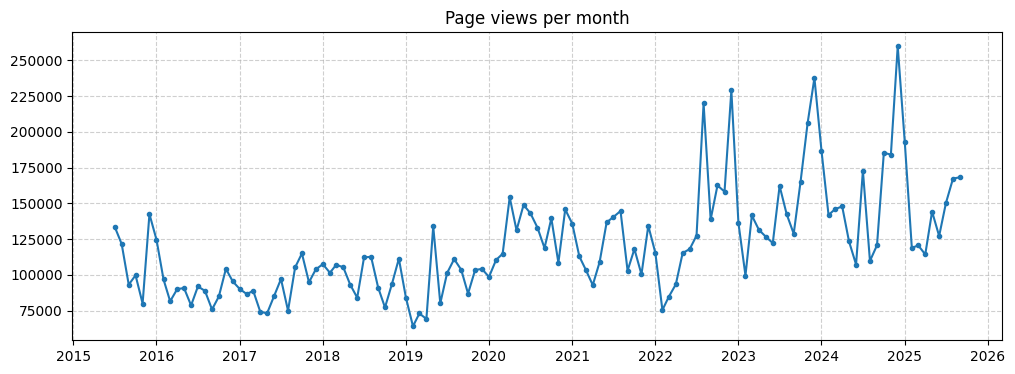

In [6]:
df.index = pd.to_datetime(df.index)
df = df.asfreq('MS')

plt.figure(figsize=(12,4))
plt.plot(df["Views"], color="#1f77b4", marker='o', markersize=3)
plt.title("Page views per month")

custom_grid(plt)

plt.show()

### 1) RNN

**RNN** (Recurrent Neural Network) - type of neural network designed for sequential data , such as **time series**, text, audio, and any data where order matters.

#### Normalize data to [0-1]

In [306]:
ts = df['Views'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
ts_scaled = scaler.fit_transform(ts)

comparison = pd.DataFrame({
    'Original': ts.flatten(),
    'Scaled (0-1)': ts_scaled.flatten()
}, index=df.index)

comparison.head(5)

,Original,Scaled (0-1)
Date,,
2015-07-01,133772,0.356172
2015-08-01,121582,0.293885
2015-09-01,93157,0.148644
2015-10-01,99713,0.182143
2015-11-01,79982,0.081325


#### Convert into a sequance

With 1-difference sequance RNN would capture only last time point relationship.
So instead of this:

* X[n] - Normalized  views at time n-1
* y[n] - Normalized views at time n

I use sequances: 

* X[n] - Window of data with len 12 at time n
* y[n] - Window if data with len 5, at time n + 12

For example if S - my series, then: 

`X[0] = [S[0], S[1], S[2] ... S[11]]`

`X[1] = [S[1], S[2], S[3] ... S[12]]`

Also as we predict 5 steps, instead of recursion I train model to make 5-length prediction at once, 
training it with 5-length targets respectively: 

`y[0] = [S[12], S[13]], S[14], S[15], S[16]]`

`y[1] - [S[13], S[14]], S[15], S[16], S[17]]`

In [307]:
window = 12
future_steps = 5

def create_sequences_multi_step(data, window, future_steps):
    X, y = [], []
    for i in range(window, len(data) - future_steps + 1):
        X.append(data[i-window:i])
        y.append(data[i:i+future_steps].flatten())  
    return np.array(X), np.array(y)

X, y = create_sequences_multi_step(ts_scaled, window, future_steps)

X = X.reshape((X.shape[0], X.shape[1], 1))

Example:

In [308]:
for i in range(3):
    print(f"Sequence {i}:")
    print("X:", X[i].flatten())  
    print("y:", y[i])
    print("-" * 50)

Sequence 0:
X: [0.35617166 0.29388531 0.14864416 0.18214288 0.08132482 0.4006714
 0.30922441 0.16707459 0.0893776  0.13274811 0.13657522 0.07461077]
y: [0.14218559 0.12657057 0.06007389 0.106362   0.20532525]
--------------------------------------------------
Sequence 1:
X: [0.29388531 0.14864416 0.18214288 0.08132482 0.4006714  0.30922441
 0.16707459 0.0893776  0.13274811 0.13657522 0.07461077 0.14218559]
y: [0.12657057 0.06007389 0.106362   0.20532525 0.16041674]
--------------------------------------------------
Sequence 2:
X: [0.14864416 0.18214288 0.08132482 0.4006714  0.30922441 0.16707459
 0.0893776  0.13274811 0.13657522 0.07461077 0.14218559 0.12657057]
y: [0.06007389 0.106362   0.20532525 0.16041674 0.13302403]
--------------------------------------------------


#### Train\Test split (2:1)

In [309]:
train_size = int(len(X) * 2/3)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

#### Build RNN network

In [301]:
model = Sequential([Input(shape=(window, 1)), SimpleRNN(50, activation='tanh'), Dense(future_steps)])

model.compile(loss='mse', optimizer='adam')

#### Fit model on Series train data

In [302]:
history = model.fit(X_train, y_train, epochs=150, batch_size=1, verbose=0)

#### Predict test values

In [303]:
pred_test_scaled = model.predict(X_test)
pred_test = scaler.inverse_transform(pred_test_scaled)
pred_test_rnn = pred_test

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


#### Predict 5 future values

In [304]:
last_window = ts_scaled[-window:].reshape(1, window, 1)
future_scaled = model.predict(last_window)
future_predictions = scaler.inverse_transform(future_scaled).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


#### Actual vs Predicted plot

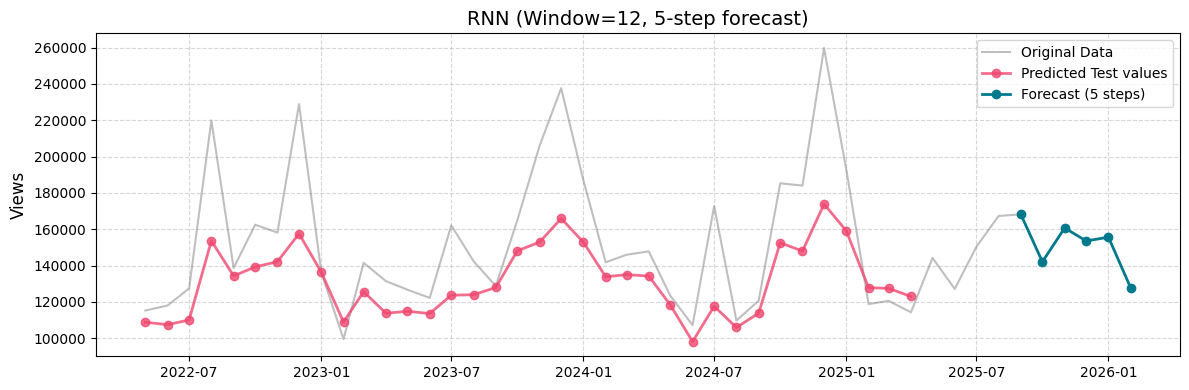

In [305]:
test_start_idx = train_size + window
plot_start_idx = test_start_idx - 1
plot_end_idx = len(df) 

test_dates = df.index[test_start_idx - 1:test_start_idx + len(pred_test) - 1] 
last_date = df.index[-1] 

future_line = np.concatenate(([df['Views'].iloc[-1]], future_predictions))
future_line_dates = pd.date_range(start=df.index[-1], periods=future_steps + 1, freq='MS') 

plt.figure(figsize=(12,4)) 
# real values
plt.plot(df.index[plot_start_idx:plot_end_idx], df['Views'][plot_start_idx:plot_end_idx], label='Original Data', color='gray', alpha=0.5, linewidth=1.5) 
# test predicted 
plt.plot(test_dates, pred_test[:,0], label='Predicted Test values', color='#ef476f',  marker='o', linewidth=2, alpha=0.8) 
# 5-step prediction
plt.plot(future_line_dates, future_line, label='Forecast (5 steps)', color='#00798c', marker='o', linewidth=2) 

plt.title("RNN (Window=12, 5-step forecast)", fontsize=14) 
plt.ylabel("Views", fontsize=12) 
plt.legend(fontsize=10) 
plt.grid(True, linestyle='--', alpha=0.5)  
plt.tight_layout() 

plt.show()

***Conclusion***

*In general, at first I tried to use a sequence with a difference of one. Accordingly, the prediction went one step forward, and for the next steps recursion was used. However, then for 5 steps forward I just had a downward graph, which was of little use as a forecast.*

*So a different approach was used: the neuron takes 12 values as input and predicts the next 5. This allows you to better see the annual relationship and makes more sense in the forecast of the next 5 steps.*

*According to the plot, the test data reproduces the real data quite well. The model has the OMS method, which eliminates large deviations, so the predicted data does not reach the real ones in terms of the strength of the spread. It also turned out to be quite interesting for the forecast for 5 steps forward, which also in theory could have a larger variance.*

    
&nbsp;

### 2) LSTM

**LSTM** (Long Short-Term Memory) is a special type of **RNN** designed to remember information over long sequences.

#### ! Repeat next steps using RNN code:

* Normalize data to [0-1]
* Convert into a Sequance
* Train\Test split (2:1)

#### Build RNN network

In [310]:
model = Sequential([Input(shape=(window, 1)), LSTM(50, activation='tanh'), Dense(future_steps)])

model.compile(loss='mse', optimizer='adam')

#### Fit model on Series train data

In [311]:
history = model.fit(X_train, y_train, epochs=150, batch_size=1, verbose=0)

#### Predict test values

In [312]:
pred_test_scaled = model.predict(X_test)
pred_test = scaler.inverse_transform(pred_test_scaled)
pred_test_lstm = pred_test

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


#### Predict 5 future values

In [313]:
last_window = ts_scaled[-window:].reshape(1, window, 1)
future_scaled = model.predict(last_window)
future_predictions = scaler.inverse_transform(future_scaled).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


#### Actual vs Predicted plot

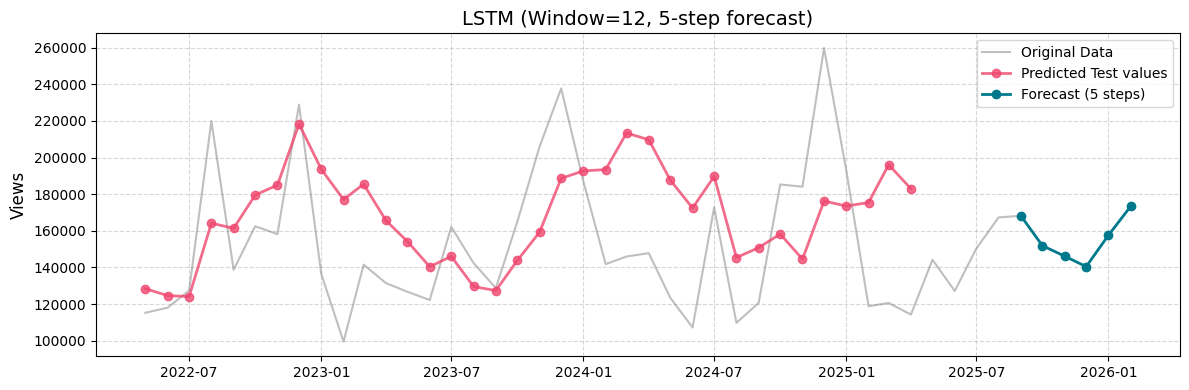

In [314]:
test_start_idx = train_size + window
plot_start_idx = test_start_idx - 1
plot_end_idx = len(df)

test_dates = df.index[test_start_idx - 1:test_start_idx + len(pred_test) - 1]

future_line = np.concatenate(([df['Views'].iloc[-1]], future_predictions))
future_line_dates = pd.date_range(start=df.index[-1], periods=future_steps + 1, freq='MS')

plt.figure(figsize=(12,4))
# real values
plt.plot(df.index[plot_start_idx:plot_end_idx], df['Views'][plot_start_idx:plot_end_idx], label='Original Data', color='gray', alpha=0.5, linewidth=1.5)
# test predicted 
plt.plot(test_dates, pred_test[:,0], label='Predicted Test values', color='#ef476f', marker='o', linewidth=2, alpha=0.8)
# 5-step prediction
plt.plot(future_line_dates, future_line, label='Forecast (5 steps)', color='#00798c', marker='o', linewidth=2)

plt.title("LSTM (Window=12, 5-step forecast)", fontsize=14)
plt.ylabel("Views", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

***Conclusion***

*Unlike RNN, LSTM is better at remembering long-term connections and patterns. As we can see from the plot, this model has bolder predictions, the data clearly has a greater variance. Although the line looks a little bit skewed.*

*Regarding the predictions 5 steps ahead, it is difficult to say which model performed better. RNN gave a forecast that views would fall at the beginning of the year, which is generally a true trend for this series. At the same time, LSTM predicted a stable start and a sharp rise during the New Year holidays.*

    
&nbsp;

### 3) Additional research

#### Residuals: RNN vs LSTM 

In [318]:
y_test_actual = df['Views'].values[train_size + window : train_size + window + len(pred_test_rnn)]

rnn_residuals = y_test_actual - pred_test_rnn[:,0]
lstm_residuals = y_test_actual - pred_test_lstm[:,0]

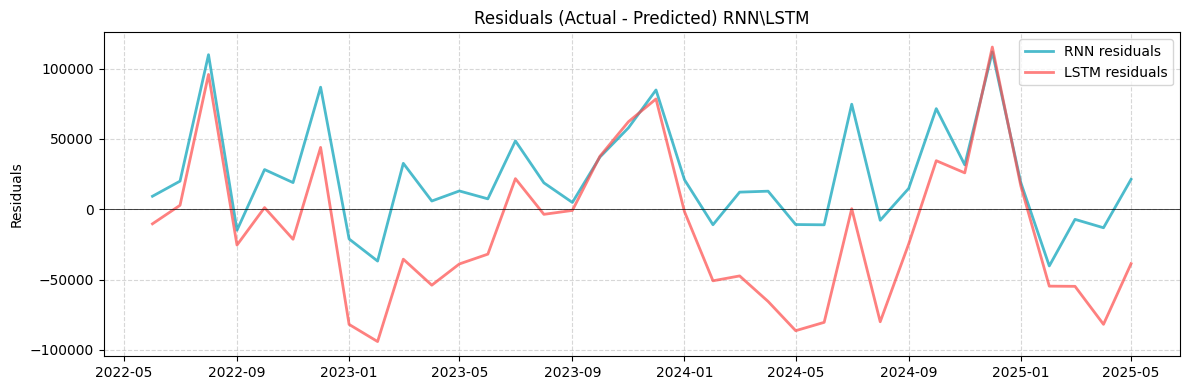

In [331]:
plt.figure(figsize=(12,4))

plt.plot(df.index[train_size + window : train_size + window + len(pred_test_rnn)], rnn_residuals, label='RNN residuals', linewidth=2, color='#009fb7', alpha=0.7)
plt.plot(df.index[train_size + window : train_size + window + len(pred_test_lstm)], lstm_residuals, label='LSTM residuals', linewidth=2, color='#fe4a49', alpha=0.7)

plt.axhline(0, color='black', linewidth=0.5)
plt.title("Residuals (Actual - Predicted) RNN\LSTM")
plt.ylabel("Residuals")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

***Conclusion***

*Residual analysis was performed for both the RNN and the LSTM. In fact, both models have somewhat similar predictions. Some time points are almost identical. The LSTM model was more confident in predicting increased views. Such jumps in views are well synchronized with the second part of the time series, where real views also often had sharp jumps.*

*But at the same time, it can be difficult to see the exact location of the jumps, so in general the LSTM has larger residuals, especially negative ones. The RNN residuals are also sometimes inflated, but overall they look more consistent and reliable.*

    
&nbsp;